In [1]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import os
import scipy
import pickle

from neurolib.models.aln import ALNModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=4)

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.getcwd()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


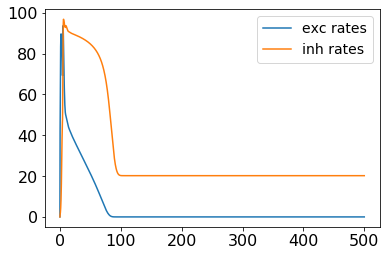

[5.2063e-05 2.0196e+01]


In [2]:
aln = ALNModel()

aln.params['duration'] = 500.

# no noise
aln.params.sigma_ou = 0.

control0 = aln.getZeroControl()

# external currents for steady state
aln.params.ext_exc_current = 2.3
aln.params.ext_inh_current = 2.

aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()
    
steady_rates = np.zeros((2))
steady_rates[0] = aln.rates_exc[0,-1]
steady_rates[1] = aln.rates_inh[0,-1]

print(steady_rates)

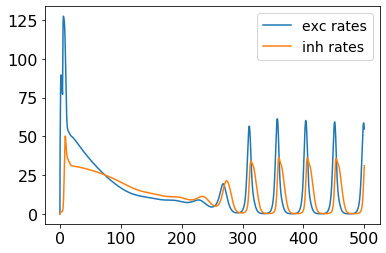

In [3]:
# external currents for oscillation
aln.params.ext_exc_current = 2.3
aln.params.ext_inh_current = 0.

aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()

state_vars = aln.state_vars

osc_init = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        osc_init[i] = aln.state[state_vars[i]][0]
    else:
        osc_init[i] = aln.state[state_vars[i]][0,-1]

In [4]:
init_vars = aln.init_vars

def setinitvars(vars):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = vars[sv]
                else:
                    aln.params[init_vars[iv]][0] = vars[sv]

In [5]:
dur = 3000.
dur_pre = 100.
dur_post = 500.
aln.params.duration = dur

tol = 1e-12
incl_step = int(1. + aln.params.duration/aln.params.dt)
start_step = 10.
test_step = 1e-6

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

## C) Oscillation to low state
- adaptation
- default delay
- max control current 5nA
- w_p = w_e = w_s = 1

In [6]:
cost.setParams(1.0, 1.0, 1.0)
max_cntrl = 5. * 5.

setinitvars(osc_init)
max_it = 10
alg = "A1"
case = "C"

aln.params.duration = dur

# set high state rates as target
target_A1 = aln.getZeroTarget()
target_A1[:,0,:] = steady_rates[0]
target_A1[:,1,:] = steady_rates[1] 

control0 = aln.getZeroControl()
#control0[:,1,:] =1.5
control0[:,1,:] =2.5

bestControlA_A1, bestStateA_A1, costA_A1, runtimeA_A1, grad = aln.A1(control0, target_A1, c_scheme, u_mat, u_scheme,
        max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

set cost params
RUN  0 , total integrated cost =  384574.9401026395
RUN  1 , total integrated cost =  8286.180167949178
RUN  2 , total integrated cost =  6277.020313640458
RUN  3 , total integrated cost =  6193.840276989648
RUN  4 , total integrated cost =  6171.248391336303
RUN  5 , total integrated cost =  6160.156359340895
RUN  6 , total integrated cost =  6154.4226615082425
RUN  7 , total integrated cost =  6150.197121360688
RUN  8 , total integrated cost =  6147.110584434929
RUN  9 , total integrated cost =  6144.413710288673


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  10 , total integrated cost =  6142.37955308283
Improved over  10  iterations by  98.40281336286668  percent.
Problem in initial value trasfer:  Vmean_exc -56.822718393000926 -56.84110238982399
Problem in initial value trasfer:  Vmean_exc -72.2842630101377 -72.28430581025833


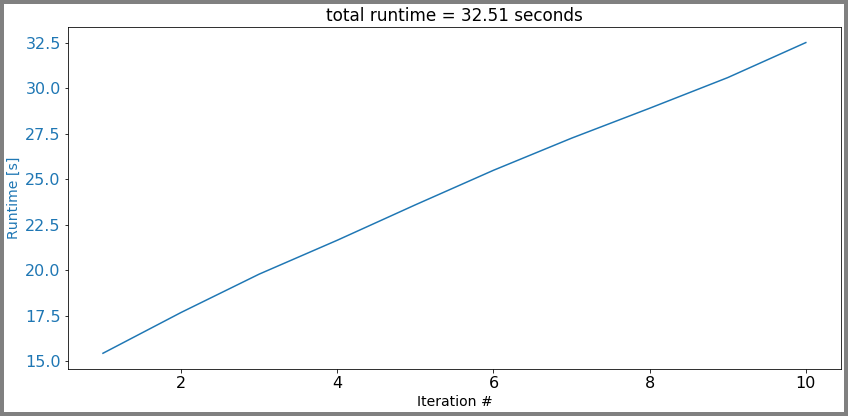

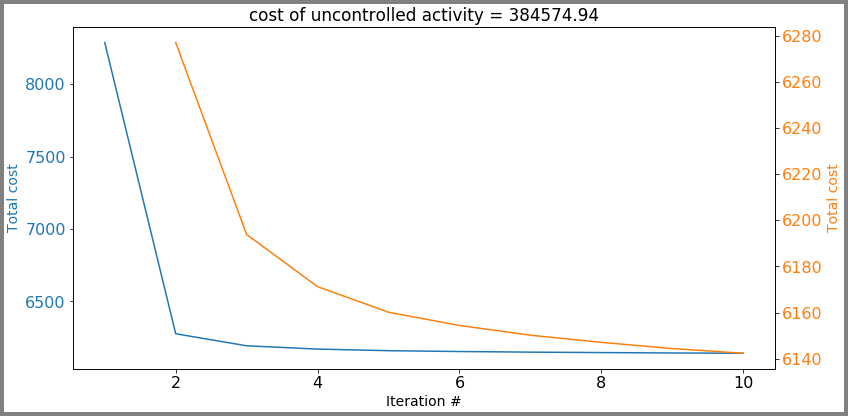

In [7]:
plotFunc.plot_runtime(runtimeA_A1, path, str("p1_e1_s1_u1nA_LowHigh_runtime_" + case + "_" + alg) )
plotFunc.plot_convergence(costA_A1, path, str("p1_e1_s1_u1nA_LowHigh_cost_" + case + "_" + alg) )

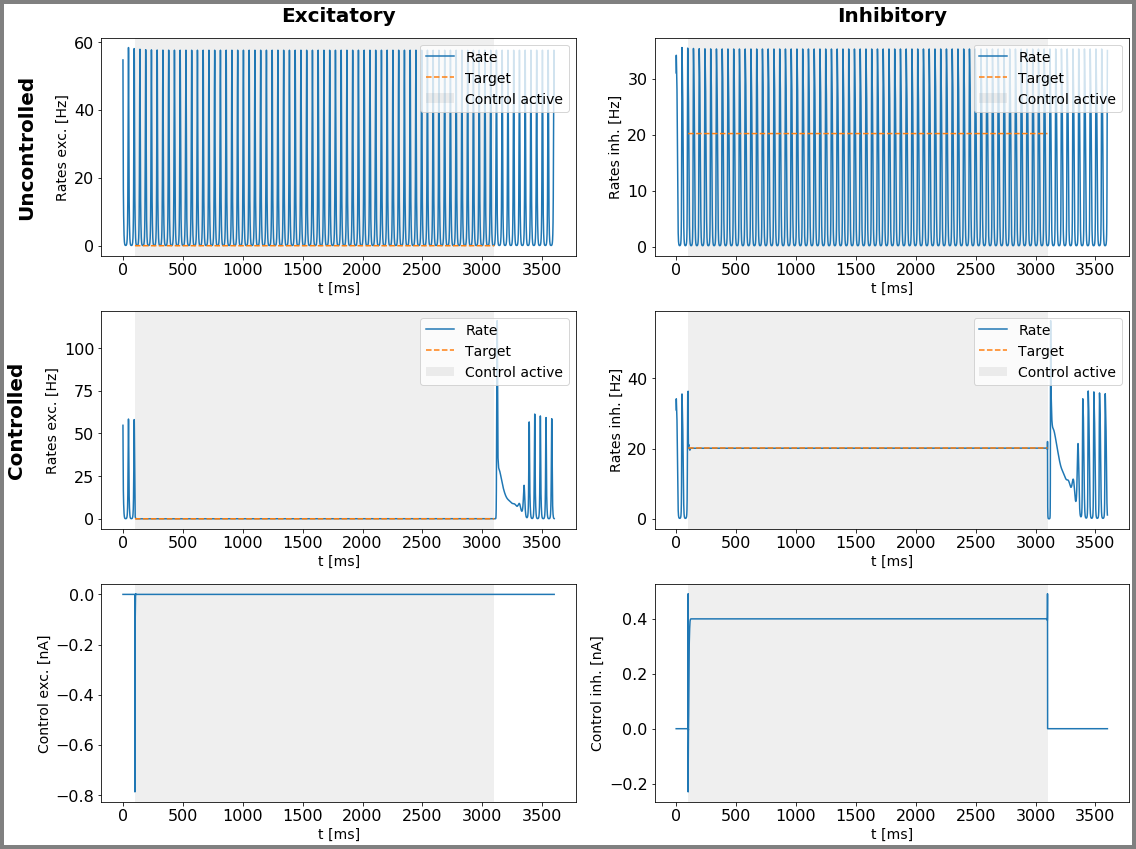

In [8]:
plotFunc.plot_control(aln, bestControlA_A1, dur, dur_pre, dur_post, osc_init, target_A1,
                      path, filename_ = str('p1_e1_s1_u1nA_LowHigh_' + case + "_" + alg))

In [9]:
dur = 100.
dur_pre = 100.
dur_post = 100.
aln.params.duration = dur

setinitvars(osc_init)
max_it = 3
alg = "A2"
case = "C"

aln.params.duration = dur

# set high state rates as target
target_A2 = aln.getZeroTarget()
target_A2[:,0,:] = steady_rates[0]
target_A2[:,1,:] = steady_rates[1] 
control0 = aln.getZeroControl()


bestControlA_A2, bestStateA_A2, costA_A2, runtimeA_A2 = aln.A2(control0, target_A2,
        max_iteration_ = max_it,  tolerance_ = tol, include_timestep_ = incl_step,
        start_step_ = start_step, test_step_ = test_step, max_control_ = max_cntrl,
        t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

RUN  0 , total integrated cost:  31335.696917500594
RUN  1 , total integrated cost:  11061.281349726074
RUN  2 , total integrated cost:  10123.369331352547


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  3 , total integrated cost:  9816.052252554138
Improved over  3  iterations by  69  percent.
Problem in initial value trasfer:  Vmean_exc -56.822718393000926 -56.84110238982399
Problem in initial value trasfer:  Vmean_exc -64.55895332081934 -64.66312301529072


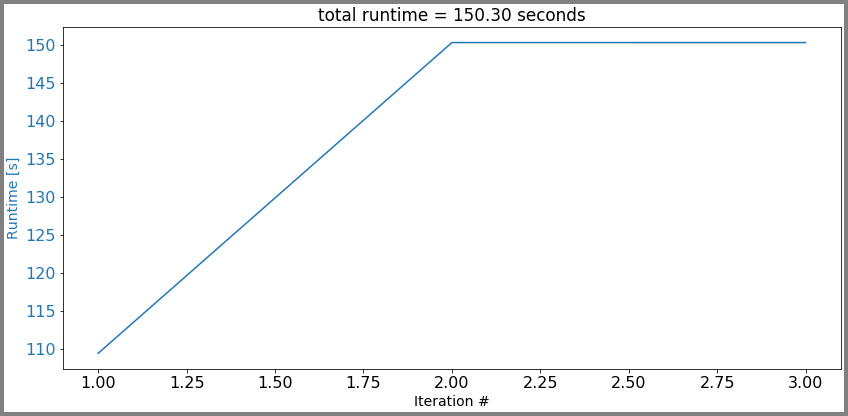

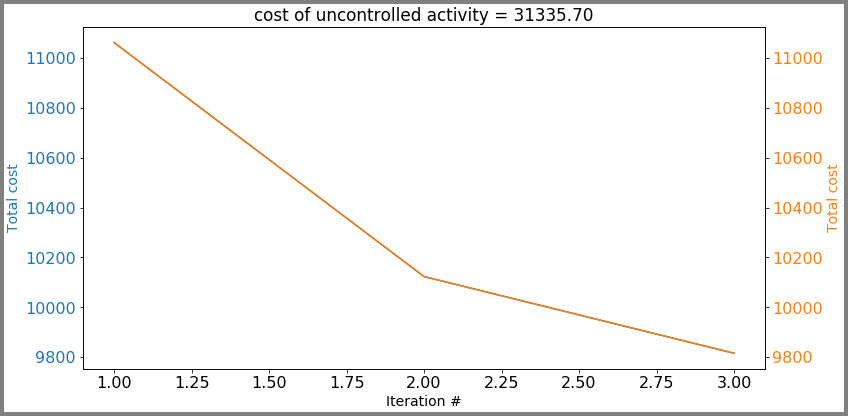

In [10]:
plotFunc.plot_runtime(runtimeA_A2, path, str("p1_e1_s1_u1nA_LowHigh_runtime_" + case + "_" + alg) )
plotFunc.plot_convergence(costA_A2, path, str("p1_e1_s1_u1nA_LowHigh_cost_" + case + "_" + alg) )

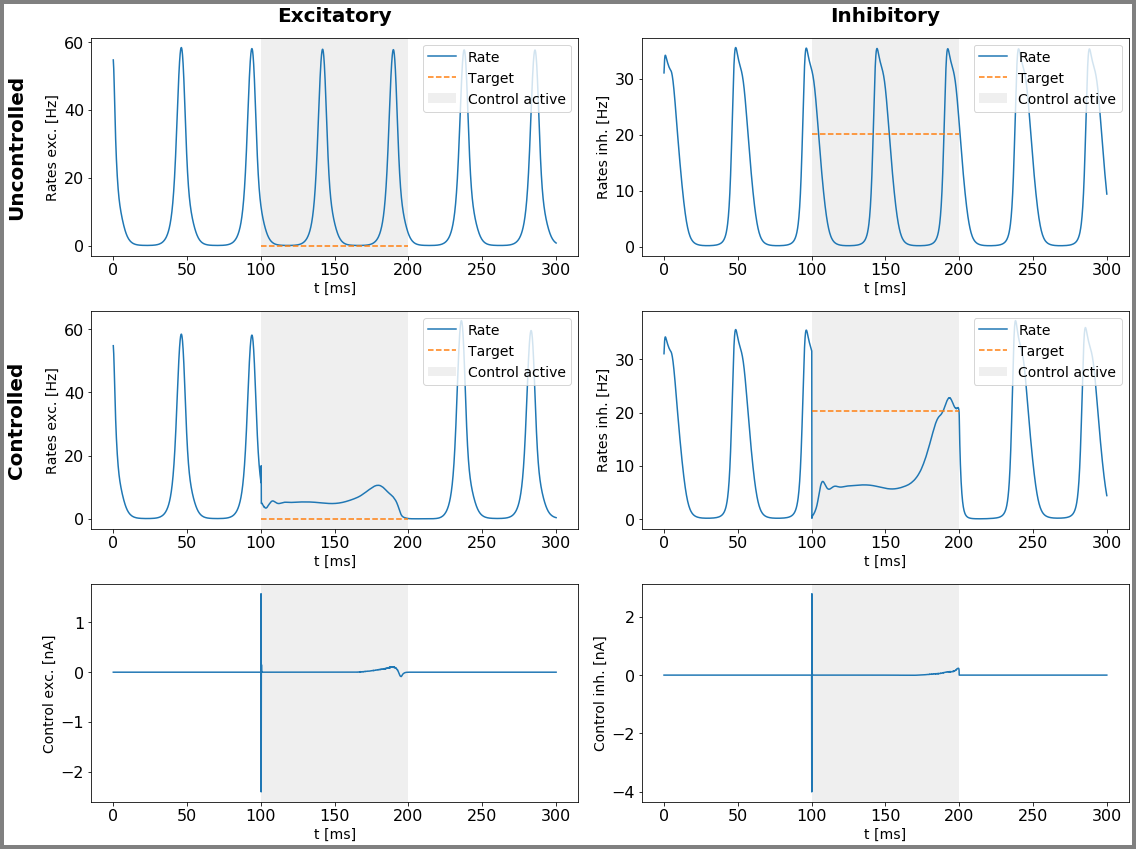

In [11]:
plotFunc.plot_control(aln, bestControlA_A2, dur, dur_pre, dur_post, osc_init, target_A2,
                      path, filename_ = str('p1_e1_s1_u1nA_LowHigh_' + case + "_" + alg))